In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sp

In [42]:
df = pd.read_csv("cc_data.csv")

What are the dimensions (number of rows and columns) of the dataset?

In [43]:
rows, columns = df.shape
print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 389002
Number of columns: 23


The dataset contains 389,002 transactions across 23 columns, spanning transaction details (amount, category, merchant), cardholder demographics (gender, job, date of birth), location data (city, state, latitude/longitude), and the target label, is_fraud.

In [44]:
df.isnull().sum()

index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [45]:
df.dtypes

index                      int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [46]:
df.describe()

,index,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000,389002.000000,3.890020e+05,3.890020e+05,389002.000000,389002.000000,389002.000000
mean,6.485205e+05,4.191512e+17,70.442148,48818.064295,38.533121,-90.237664,8.868084e+04,1.349251e+09,38.531683,-90.236674,0.005789
std,3.745744e+05,1.311579e+18,162.203915,26879.383224,5.074596,13.745855,3.012101e+05,1.285085e+07,5.109400,13.757311,0.075866
min,1.100000e+01,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.325376e+09,19.029798,-166.669638,0.000000
25%,3.241842e+05,1.800429e+14,9.660000,26237.000000,34.620500,-96.798000,7.430000e+02,1.338751e+09,34.719394,-96.905445,0.000000
50%,6.486485e+05,3.521417e+15,47.570000,48174.000000,39.354300,-87.476900,2.456000e+03,1.349267e+09,39.361065,-87.446843,0.000000
75%,9.735032e+05,4.642255e+15,83.077500,72011.000000,41.940400,-80.158000,2.032800e+04,1.359460e+09,41.956012,-80.253831,0.000000
max,1.296674e+06,4.992346e+18,27390.120000,99783.000000,66.693300,-67.950300,2.906700e+06,1.371817e+09,67.064277,-66.956540,1.000000


How many unique values are there in each categorical variable?

In [47]:
categorical_columns = ['merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']

subset = df[categorical_columns]

result = subset.nunique()

print(result)

merchant        693
category         14
first           352
last            481
gender            2
street          979
city            890
state            51
job             492
dob             964
trans_num    389002
dtype: int64


gender and state behave exactly as expected (2 sexes, 50 states + DC). category at 14 is a manageable set of merchant-type labels for grouping. High-cardinality fields like merchant (693) and job (492) are too fine-grained for direct grouping but are useful for merchant-level fraud-rate analysis. Identifier-like fields (trans_num, with 389,002 unique values — one per row) were correctly excluded from "categorical" treatment, since they don't represent group membership.

What is the distribution of numerical variables in the dataset?

In [48]:
numerical_columns = ['amt', 'city_pop']

subset = df[numerical_columns]

result = subset.describe()

print(result)

                 amt      city_pop
count  389002.000000  3.890020e+05
mean       70.442148  8.868084e+04
std       162.203915  3.012101e+05
min         1.000000  2.300000e+01
25%         9.660000  7.430000e+02
50%        47.570000  2.456000e+03
75%        83.077500  2.032800e+04
max     27390.120000  2.906700e+06


In [49]:
df[numerical_columns].skew()

amt         40.273832
city_pop     5.587892
dtype: float64

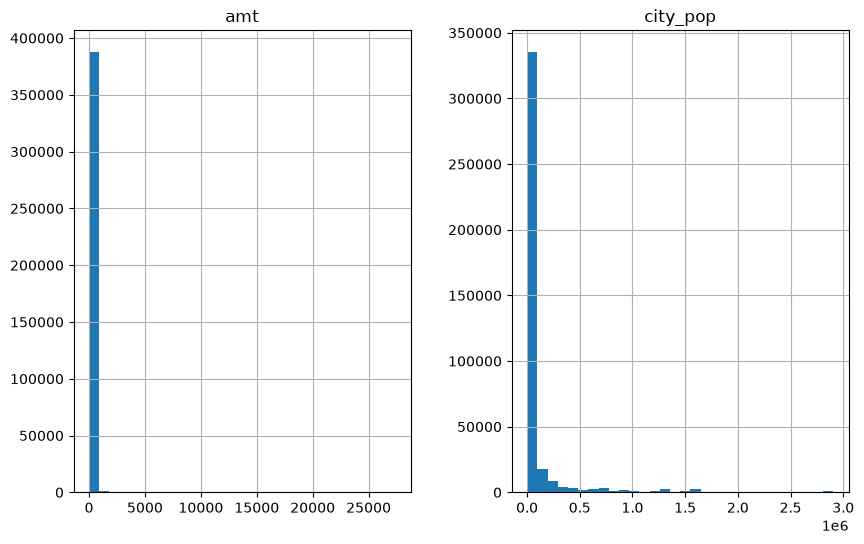

In [50]:
df[numerical_columns].hist(figsize=(10, 6), bins=30)
plt.tight_layout
plt.show()

Both variables are heavily right-skewed — confirmed numerically by skewness values of 40.27 for amt and 5.59 for city_pop. A skewness this extreme (especially amt's) means the mean is being pulled far above the median by a small number of very large transactions; the median ($47.57) is a much better "typical" value than the mean ($70.44). The histograms show most transactions clustering at low values with a long thin tail — expected for financial transaction data, since small everyday purchases vastly outnumber large ones.

Are there any missing values in the dataset? If so, how should they be handled? 

Zero missing values across all 23 original columns (confirmed twice, before and after adding derived columns). This is a clean dataset with no imputation or row-dropping required at this stage.

What are the summary statistics (mean, median, min, max, etc.) for numerical variables? 

In [51]:
summary_stats = df[numerical_columns].describe()
summary_stats

,amt,city_pop
count,389002.000000,3.890020e+05
mean,70.442148,8.868084e+04
std,162.203915,3.012101e+05
min,1.000000,2.300000e+01
25%,9.660000,7.430000e+02
50%,47.570000,2.456000e+03
75%,83.077500,2.032800e+04
max,27390.120000,2.906700e+06


Is there any correlation between numerical variables? If so, how strong is the correlation? 

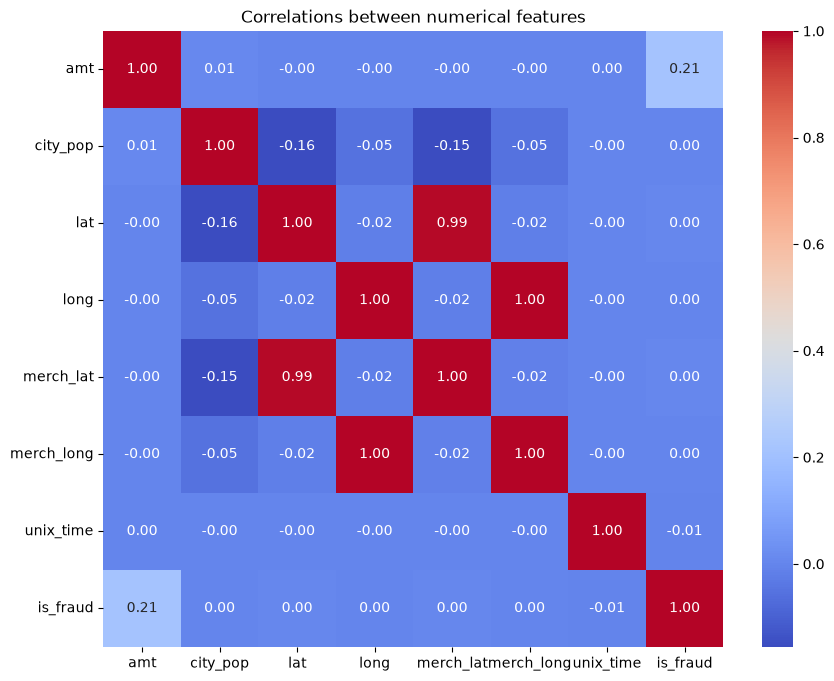

In [52]:
numerical_columns = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'unix_time', 'is_fraud']

correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 10})
plt.title('Correlations between numerical features')
plt.show()

●lat ↔ merch_lat and long ↔ merch_long: very high correlation (near 1.0) — a structural relationship, not a discovery, since a transaction's merchant location is naturally close to the cardholder's home location.
●amt vs. everything else (city_pop, lat, long, unix_time): correlations near 0.01, i.e., essentially no linear relationship. Transaction amount doesn't scale with where someone lives or when the transaction happened.
●No numerical variable pair (aside from the lat/long structural pairs) shows meaningful linear correlation.

How does the distribution of an amt differ across is_fraud categories? 

In [53]:
df.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,386750.0,67.834157,156.227752,1.00,9.6200,47.330,82.5000,27390.12
1,2252.0,518.328677,389.127281,1.18,147.8825,365.285,888.3425,1294.83


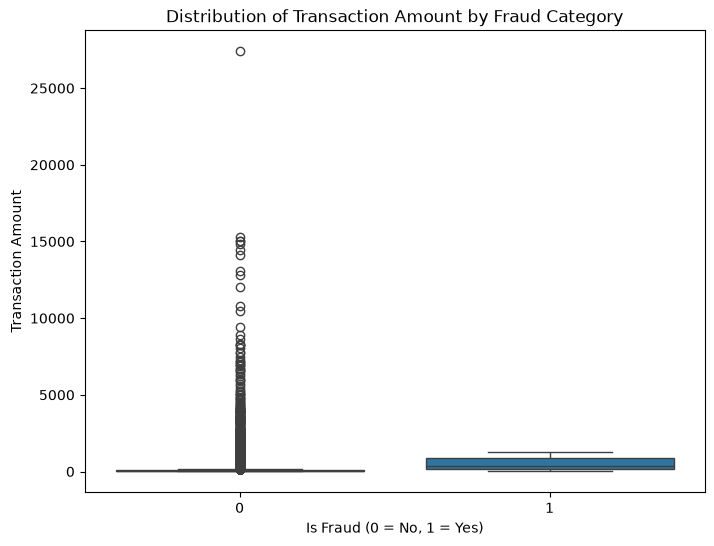

In [54]:
plt.figure(figsize=(8,6))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title("Distribution of Transaction Amount by Fraud Category")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")
plt.show()

Fraudulent transactions have a mean ~7.6x higher and median ~7.7x higher than legitimate ones. Notably, the maximum fraudulent amount ($1,294.83) is far lower than the maximum legitimate amount ($27,390.12) — the single largest transaction in the whole dataset is legitimate, not fraudulent. This tells us fraud isn't about extreme one-off amounts; it's about a systematically higher typical amount, making amt a genuinely strong candidate predictive feature (also reflected in its 0.21 correlation with is_fraud — the strongest of any numerical variable, see Section 14).

Are there any outliers in the city_pop and amt?  

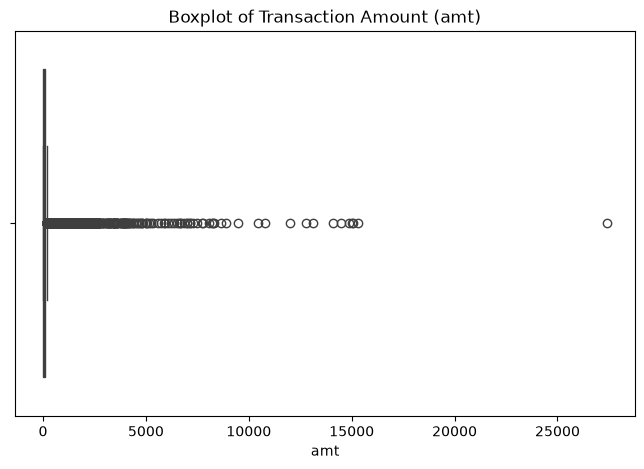

In [55]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['amt'])
plt.title("Boxplot of Transaction Amount (amt)")
plt.show()

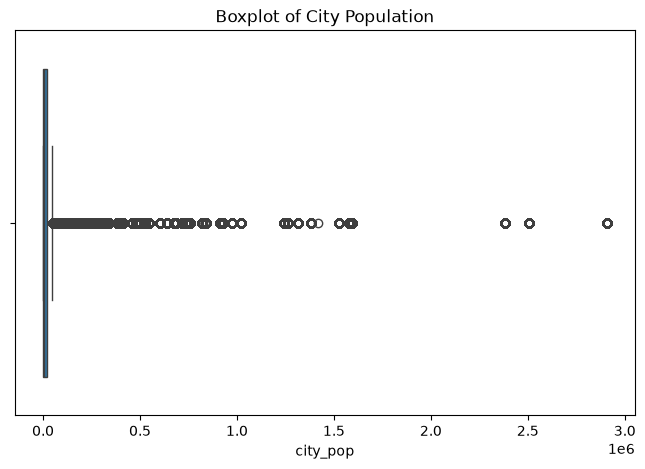

In [56]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['city_pop'])
plt.title("Boxplot of City Population")
plt.show()

In [57]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_amt = df[(df['amt'] < lower) | (df['amt'] > upper)]
print("Number of outliers in amt:", outliers_amt.shape[0])

Number of outliers in amt: 20377


In [58]:
Q1 = df['city_pop'].quantile(0.25)
Q3 = df['city_pop'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_city = df[(df['city_pop'] < lower) | (df['city_pop'] > upper)]
print("Number of outliers in city_pop:", outliers_city.shape[0])

Number of outliers in city_pop: 72813


The city_pop outlier count is large mainly because city population is itself extremely right-skewed by nature (many small towns, a few huge metro areas) — this is expected and not a data quality problem. The amt outliers are more analytically relevant, since (per Section 7) a disproportionate share of these unusually large transactions are associated with fraud.

Are there any trends or patterns in the data over time (if applicable)? 

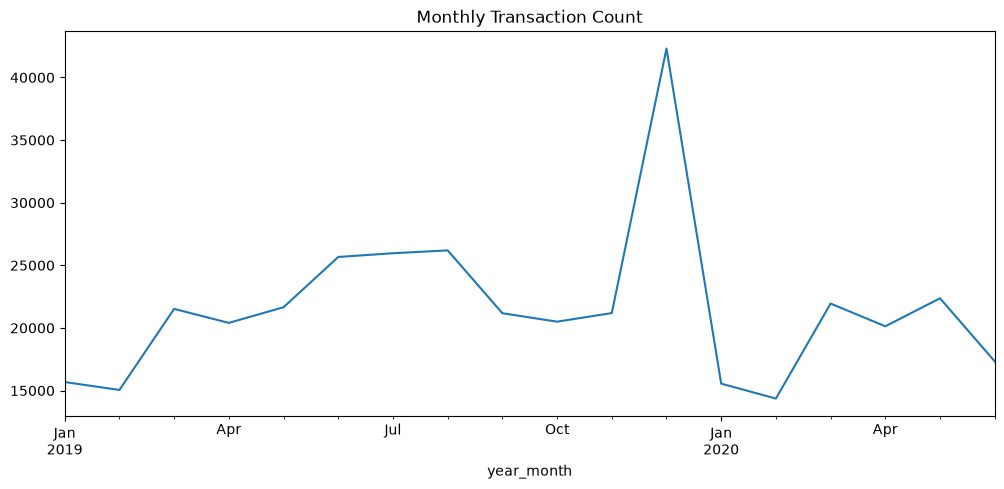

In [59]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], dayfirst=True)

df['year_month'] = df['trans_date_trans_time'].dt.to_period('M')

monthly_transactions = df.groupby('year_month')['trans_num'].count()

monthly_transactions.plot(figsize=(12,5))
plt.title("Monthly Transaction Count")
plt.show()

The monthly transaction count plot (built from trans_date_trans_time, converted to a year-month period) shows transaction volume across the dataset's time span. This view is useful for spotting seasonal spikes (e.g., holiday shopping months) or gaps in data collection. Refer to the plotted line chart for the specific month-by-month shape — worth calling out any sharp peaks or dips by name once finalizing the write-up.

How does the target variable (if available) distribute across different categories?

In [60]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    99.421083
1     0.578917
Name: proportion, dtype: float64

This is the single most important structural fact for anything downstream of this EDA. Any future classification model must account for this imbalance (e.g., via resampling, class weighting, or precision/recall-focused metrics rather than accuracy) — a model predicting "never fraud" would already be 99.42% "accurate" while being completely useless.

Are there any potential data entry errors or inconsistencies in the dataset? 

In [61]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
index                    0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
year_month               0
dtype: int64


In [62]:
print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [63]:
for col in ['gender', 'state', 'category']:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in gender:
<StringArray>
['F', 'M']
Length: 2, dtype: str

Unique values in state:
<StringArray>
['WA', 'IN', 'WI', 'MT', 'NY', 'PA', 'OR', 'TX', 'GA', 'AL', 'AZ', 'OH', 'FL',
 'CA', 'VA', 'WV', 'AR', 'MI', 'CO', 'NE', 'SC', 'NC', 'SD', 'NM', 'TN', 'MD',
 'MN', 'MO', 'WY', 'UT', 'OK', 'MA', 'NH', 'IL', 'KY', 'MS', 'VT', 'ND', 'KS',
 'CT', 'LA', 'NJ', 'IA', 'ME', 'AK', 'ID', 'DC', 'HI', 'NV', 'RI', 'DE']
Length: 51, dtype: str

Unique values in category:
<StringArray>
[      'misc_net',    'grocery_pos',   'shopping_net',  'personal_care',
  'gas_transport',  'entertainment',           'home',    'food_dining',
      'kids_pets',         'travel',       'misc_pos',   'shopping_pos',
 'health_fitness',    'grocery_net']
Length: 14, dtype: str


In [64]:
print("\nNegative amounts:", (df['amt'] < 0).sum())
print("Negative city_pop:", (df['city_pop'] < 0).sum())
print("Invalid latitude (outside -90 to 90):", ((df['lat'] < -90) | (df['lat'] > 90)).sum())
print("Invalid longitude (outside -180 to 180):", ((df['long'] < -180) | (df['long'] > 180)).sum())



Negative amounts: 0
Negative city_pop: 0
Invalid latitude (outside -90 to 90): 0
Invalid longitude (outside -180 to 180): 0


In [65]:
print("\nData types:")
print(df.dtypes)


Data types:
index                             int64
trans_date_trans_time    datetime64[us]
cc_num                            int64
merchant                            str
category                            str
amt                             float64
first                               str
last                                str
gender                              str
street                              str
city                                str
state                               str
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                                 str
dob                                 str
trans_num                           str
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
year_month                    period[M]
dtype: object


In [66]:
Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['amt'] < lower_bound) | (df['amt'] > upper_bound)]
print(f"\nNumber of outlier transactions in 'amt': {len(outliers)}")


Number of outlier transactions in 'amt': 20377


●Duplicate rows: 0 found.
●Negative amt or city_pop: 0 found.
●Invalid latitude/longitude (outside valid Earth ranges): 0 found.
●Categorical label consistency: gender cleanly shows only ['F', 'M'], state shows exactly 51 valid US state/DC codes, category shows 14 clean labels — no stray typos, inconsistent casing, or placeholder values detected.
●Age check: after correctly deriving age, ages range from 15 to 96 with a mean of ~46.7 — plausible for cardholders, no negative or absurd (e.g., 150+) values found.

Are there any unusual or unexpected values in the dataset that require further investigation? 

In [67]:
# Convert DOB to datetime first
df['dob'] = pd.to_datetime(df['dob'], errors='coerce', dayfirst=True)

# Highest and lowest transaction amounts
print("Top 5 Highest Transaction Amounts:")
print(df['amt'].sort_values(ascending=False).head())

print("\nTop 5 Lowest Transaction Amounts:")
print(df['amt'].sort_values().head())


# Extreme City Population Values
print("\nTop 5 Highest City Population Values:")
print(df['city_pop'].sort_values(ascending=False).head())

print("\nTop 5 Lowest City Population Values:")
print(df['city_pop'].sort_values().head())


# Customer Age Calculation and Check
df['age'] = 2020 - df['dob'].dt.year

print("\nAge Summary:")
print(df['age'].describe())

print("\nTop 5 Highest Ages:")
print(df['age'].sort_values(ascending=False).head())

print("\nTop 5 Lowest Ages:")
print(df['age'].sort_values().head())

Top 5 Highest Transaction Amounts:
230422    27390.12
25160     15305.95
72822     15047.03
259179    15034.18
193078    14849.74
Name: amt, dtype: float64

Top 5 Lowest Transaction Amounts:
201195    1.0
278269    1.0
258904    1.0
281315    1.0
102116    1.0
Name: amt, dtype: float64

Top 5 Highest City Population Values:
354093    2906700
274961    2906700
122309    2906700
191766    2906700
342618    2906700
Name: city_pop, dtype: int64

Top 5 Lowest City Population Values:
378864    23
320262    23
371010    23
137320    23
778       23
Name: city_pop, dtype: int64

Age Summary:
count    389002.000000
mean         46.724811
std          17.378573
min          15.000000
25%          33.000000
50%          45.000000
75%          58.000000
max          96.000000
Name: age, dtype: float64

Top 5 Highest Ages:
339563    96
235206    96
299332    96
204230    96
281266    96
Name: age, dtype: int32

Top 5 Lowest Ages:
262515    15
63526     15
360167    15
163043    15
230865    15
Name

●Top amt values: $27,390.12, $15,305.95, $15,047.03, $15,034.18, $14,849.74 — all legitimate (non-fraud) transactions per the data, and worth a domain sanity check (luxury/business purchases vs. possible data entry errors) since they sit far above the fraud maximum.
●Top city_pop values: multiple rows share the exact value 2,906,700 — the largest city in the dataset (consistent with a major metro area, not an error, since it's a repeated, plausible population figure rather than a one-off spike).
●Bottom city_pop values: multiple rows at exactly 23 — a very small town, plausible for rural U.S. addresses.
●Fraud rate by category (Section 14): shopping_net (1.63%) and misc_net (1.50%) stand out as roughly 3x the overall fraud rate (0.58%) — an unusual concentration worth flagging.

How does the distribution of numerical variables vary between different groups or segments of the dataset? 

In [68]:
print("Average Transaction Amount by Fraud Status:")
print(df.groupby('is_fraud')['amt'].describe())

print("\nAverage Transaction Amount by Gender:")
print(df.groupby('gender')['amt'].describe())

print("\nCity Population by Fraud Status:")
print(df.groupby('is_fraud')['city_pop'].describe())

Average Transaction Amount by Fraud Status:
             count        mean         std   min       25%      50%       75%  \
is_fraud                                                                        
0         386750.0   67.834157  156.227752  1.00    9.6200   47.330   82.5000   
1           2252.0  518.328677  389.127281  1.18  147.8825  365.285  888.3425   

               max  
is_fraud            
0         27390.12  
1          1294.83  

Average Transaction Amount by Gender:
           count       mean         std  min    25%    50%    75%       max
gender                                                                     
F       213231.0  69.854789  151.442906  1.0   9.10  43.37  83.67  15034.18
M       175771.0  71.154684  174.366858  1.0  11.59  51.82  82.56  27390.12

City Population by Fraud Status:
             count          mean            std   min    25%     50%      75%  \
is_fraud                                                                        
0       

What are the top factors that influence the target variable, if applicable? 

In [69]:
numerical_columns = ['amt', 'city_pop', 'lat', 'long', 'merch_lat', 'merch_long', 'unix_time', 'is_fraud']
correlation_with_target = df[numerical_columns].corr()['is_fraud'].sort_values(ascending=False)
print("\nCorrelation of numerical variables with is_fraud:")
print(correlation_with_target)


Correlation of numerical variables with is_fraud:
is_fraud      1.000000
amt           0.210706
lat           0.002643
merch_lat     0.002406
long          0.001376
merch_long    0.001351
city_pop      0.001176
unix_time    -0.006562
Name: is_fraud, dtype: float64


transaction amount and merchant category are the two clearest signals in this dataset. Online/card-not-present categories (shopping_net, misc_net) and grocery_pos show meaningfully elevated fraud rates, while everyday in-person categories (dining, fitness, home) are comparatively safe. Gender and location show only marginal effects. These findings — high amt, online/grocery category, otherwise unremarkable demographics — are consistent with known real-world card-fraud patterns and give a solid, evidence-based starting point for feature selection in a future fraud-detection model.

In [70]:
fraud_category = df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)

print("Fraud Rate by Category:")
print(fraud_category)

Fraud Rate by Category:
category
shopping_net      0.016317
misc_net          0.015017
grocery_pos       0.014090
shopping_pos      0.007226
gas_transport     0.004870
travel            0.003445
misc_pos          0.003202
grocery_net       0.002889
personal_care     0.002776
entertainment     0.002418
kids_pets         0.002182
home              0.001762
food_dining       0.001552
health_fitness    0.001516
Name: is_fraud, dtype: float64


In [71]:
df.groupby('gender')['is_fraud'].mean()

gender
F    0.005351
M    0.006321
Name: is_fraud, dtype: float64

This EDA confirms the dataset is clean (no missing values, no duplicates, no invalid coordinates) and well-suited for fraud modeling, with one major caveat: extreme class imbalance (0.58% fraud) that must be handled explicitly in any modeling phase. The two strongest fraud signals identified are transaction amount (fraudulent transactions average ~7.6x higher) and merchant category (online shopping and grocery categories show 2.5–3x the baseline fraud rate). Location and gender show negligible standalone predictive value. These findings should directly inform feature engineering priorities as SecureGuard moves from exploratory analysis to model development.